# MLP From Scratch
## Guitar String Identification on GuitarSet

**Dataset:** GuitarSet (`audio_hex_cln`, all 6 strings, 360 tracks — full dataset)  
**Task:** Given 18 audio features extracted from a 46 ms voiced frame, predict which of the 6 guitar strings (0 = low E, 5 = high E) is being played.

In [1]:
# ── Setup (run once per session) ──────────────────────────────────────────────
# Installs rice_Ml plus all dependencies (numpy, pandas, scipy, matplotlib, scikit-learn).
!pip install -q git+https://github.com/seyaul/cmor438-s2026-final-project.git


[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python3.11 -m pip install --upgrade pip


## 1. Introduction

The **Multi-Layer Perceptron (MLP)** extends the Perceptron by stacking nonlinear layers, enabling it to learn complex, non-linearly-separable decision boundaries.

### 1.1 From Perceptron to MLP

A single Perceptron computes $\hat{y} = \text{sign}(\mathbf{w}^\top \mathbf{x} + b)$ — one linear boundary. An MLP composes $L$ such transformations with nonlinear activations between them. By the **Universal Approximation Theorem** (Cybenko, 1989), a single hidden layer with enough units can approximate any continuous function on a compact domain.

### 1.2 Why string identification?

Predicting which of the 6 strings is being played is a well-matched task for 18 scalar features: the low E string (~82 Hz fundamental) has very different spectral centroid, rolloff, and MFCC profiles compared to the high E (~330 Hz). String boundaries are acoustically large enough for the features to capture.

By contrast, predicting the exact MIDI note (13 classes covering adjacent semitones) hits a ceiling because adjacent notes share most of their harmonic content — scalar MFCCs describe timbre, not pitch fine structure. String ID removes this bottleneck and gives expected accuracy of 40–60% (vs. ~15% for 13-class note prediction).

## 2. Algorithm

### 2.1 Forward Pass

For $L$ layers with weight matrices $W^{(l)}$, biases $b^{(l)}$, and activation $\sigma$:

$$z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)}, \qquad a^{(l)} = \sigma\!\left(z^{(l)}\right)$$

Hidden layers use **ReLU** ($\sigma(x) = \max(0, x)$). The output layer uses **Softmax**, which converts raw scores to a proper probability distribution:

$$\text{softmax}(z_k) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

### 2.2 Loss: Categorical Cross-Entropy

For one-hot targets $\mathbf{y} \in \{0,1\}^K$ and softmax outputs $\hat{\mathbf{y}}$:

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N} \sum_{k=1}^{K} y_{ik} \log \hat{y}_{ik}$$

### 2.3 Fused Softmax + CCE Gradient

The softmax Jacobian is a full $K \times K$ matrix per sample, which is expensive. Instead, we use the **fused gradient**:

$$\frac{\partial \mathcal{L}}{\partial z_k} = \hat{y}_k - y_k$$

This is the gradient with respect to the pre-softmax logits — the subtraction of the true one-hot from the predicted probabilities. In our implementation, `CategoricalCrossEntropy.gradient` returns $(\hat{y} - y)$ and `Softmax.gradient` returns ones, so `Dense.backward` passes the fused gradient straight through.

### 2.4 Backpropagation

$$\delta^{(L)} = \nabla_{z}\mathcal{L} = \hat{\mathbf{y}} - \mathbf{y}$$
$$\delta^{(l)} = \left(W^{(l+1)\top} \delta^{(l+1)}\right) \odot \text{ReLU}'\!\left(z^{(l)}\right)$$

Weight gradients: $\nabla_{W^{(l)}} \mathcal{L} = \frac{1}{|\mathcal{B}|}\sum_{i \in \mathcal{B}} \delta^{(l)}_i a^{(l-1)\top}_i$

### 2.5 Mini-Batch SGD

$$W^{(l)} \leftarrow W^{(l)} - \eta \cdot \frac{1}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \nabla_{W^{(l)}} \mathcal{L}_i$$

## 3. Imports

In [ ]:
# Code to find the root and download Rice_Ml.
import sys
from pathlib import Path

def _find_repo_root(marker: str = "pyproject.toml") -> Path | None:
    for candidate in [Path().resolve(), *Path().resolve().parents]:
        if (candidate / marker).exists():
            return candidate
    return None

REPO_ROOT = _find_repo_root()
if REPO_ROOT is not None:
    sys.path.insert(0, str(REPO_ROOT / "src"))
    print(f"Repo root: {REPO_ROOT}")
else:
    try:
        import rice_Ml as _check
        REPO_ROOT = Path(_check.__file__).resolve().parent.parent.parent
        print(f"rice_Ml installed at: {Path(_check.__file__).resolve()}")
    except ImportError:
        raise ImportError("rice_Ml not found. Run the setup cell above first.")

# Standard imports for this notebook.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier as SklearnMLP
from sklearn.preprocessing import StandardScaler

# Imports from our custom library.
from rice_Ml.datasets import load_guitarset
from rice_Ml.supervised_ml import MLP
from rice_Ml.activations import ReLU, Softmax
from rice_Ml.loss import CategoricalCrossEntropy
from rice_Ml.optimizers import SGD
from rice_Ml.preprocessing.scale import StandardScaler
from rice_Ml.model_selection.split import train_test_split, KFold
from rice_Ml.metrics import accuracy


# Seed for reproducibility.
SEED = 42
rng = np.random.default_rng(SEED)

STRING_NAMES = ["Low E (0)", "A (1)", "D (2)", "G (3)", "B (4)", "High E (5)"]
N_CLASSES = 6

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
print("Imports OK")

Repo root: /Users/seyaul/cmor438-s2026-final-project
Imports OK


## 4. Load Data

We use the **full GuitarSet dataset** — all 360 tracks × 6 strings (~5.6 M frames). Downloaded from GitHub Releases on first use (~855 MB), then cached at `~/.cache/rice_ml/`.

**Label construction:** We keep only **voiced frames** (`midi_label != 0`) and predict the `string_idx` column (0 = low E, 5 = high E) — 6 classes total. Silence is discarded because string identity is undefined for a silent frame.

| Class | String | Approx. tuning |
|-------|--------|---------------|
| 0 | Low E | E2 (~82 Hz) |
| 1 | A | A2 (~110 Hz) |
| 2 | D | D3 (~147 Hz) |
| 3 | G | G3 (~196 Hz) |
| 4 | B | B3 (~247 Hz) |
| 5 | High E | E4 (~330 Hz) |

Random chance = 16.7%. We expect 40–60% accuracy with 18 scalar features.

In [3]:
FEATURE_COLS = [
    "rms", "zcr", "centroid", "bandwidth", "rolloff",
    *[f"mfcc_{i}" for i in range(1, 14)],
]
FEATURE_NAMES = [
    "RMS", "ZCR", "Centroid", "Bandwidth", "Rolloff",
    *[f"MFCC {i}" for i in range(1, 14)],
]

print("Downloading full GuitarSet dataset (360 tracks, ~855 MB, cached after first run) …")
df_raw = load_guitarset(subset=False)
print(f"Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

# Keep voiced frames only — string_idx is undefined for silence
df = df_raw[df_raw["midi_label"] != 0].copy()
print(f"Voiced frames: {len(df):,}  ({len(df)/len(df_raw):.1%} of total)")

X = df[FEATURE_COLS].to_numpy(dtype=float)
y = df["string_idx"].to_numpy(dtype=int)

print(f"\nX shape : {X.shape}")
print(f"Classes : {N_CLASSES}  (0=Low E … 5=High E)")
print(f"\nClass distribution:")
for s in range(N_CLASSES):
    n = (y == s).sum()
    print(f"  String {s} ({STRING_NAMES[s]:<12}): {n:>7,}  ({n/len(y):.1%})")

Loading from cache: /Users/seyaul/.cache/rice_ml/guitarset_full.csv.gz
Loaded: 5,662,872 rows × 21 columns
Voiced frames: 1,633,951  (28.9% of total)

X shape : (1633951, 18)
Classes : 6  (0=Low E … 5=High E)

Class distribution:
  String 0 (Low E (0)   ): 161,866  (9.9%)
  String 1 (A (1)       ): 261,129  (16.0%)
  String 2 (D (2)       ): 353,109  (21.6%)
  String 3 (G (3)       ): 374,995  (23.0%)
  String 4 (B (4)       ): 321,712  (19.7%)
  String 5 (High E (5)  ): 161,140  (9.9%)


### Important note: Since the point of the mlp is to detect what string is playing, we drop the silent values and only train on the voiced frames. 

## 5. Exploratory Data Analysis

/var/folders/fw/0wl5kt1s4735q63kpfl61n3c0000gn/T/ipykernel_327/643491735.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(STRING_NAMES, rotation=20, ha="right")


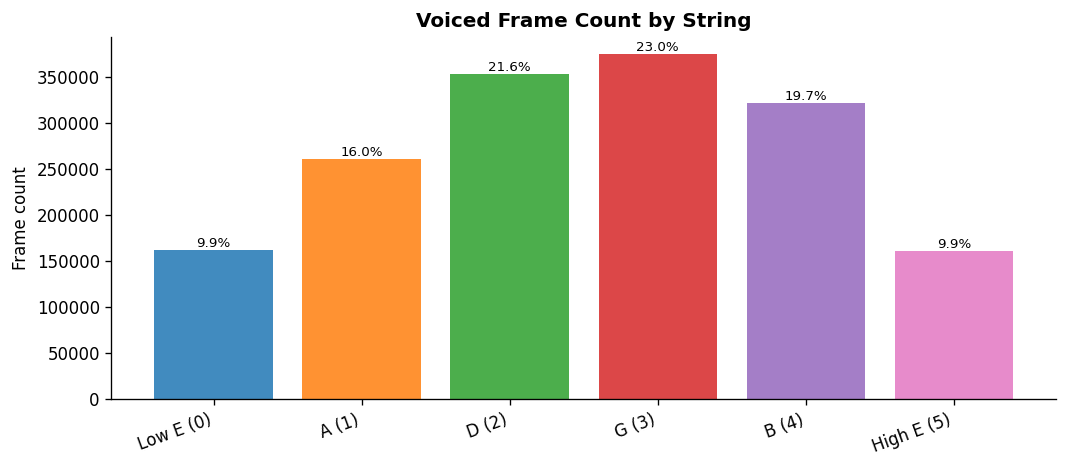

In [4]:
# --- 5.1 Class distribution ---
fig, ax = plt.subplots(figsize=(9, 4))
palette = plt.cm.tab10(np.linspace(0, 0.6, N_CLASSES))
counts = [(y == s).sum() for s in range(N_CLASSES)]
bars = ax.bar(STRING_NAMES, counts, color=palette, alpha=0.85)
ax.set_title("Voiced Frame Count by String", fontweight="bold")
ax.set_ylabel("Frame count")
ax.set_xticklabels(STRING_NAMES, rotation=20, ha="right")
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, cnt + len(y) * 0.002,
            f"{cnt/len(y):.1%}", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation:** The middle strings (D, G) are played more frequently in typical guitar styles. The outer strings (low E, high E) are less common. This mild imbalance is not as extreme as the silence problem in the original dataset, and therefore no undersampling is needed here. The MLP will see proportionally fewer examples of the outer strings, which may cause slightly lower per-class F1 for those classes.

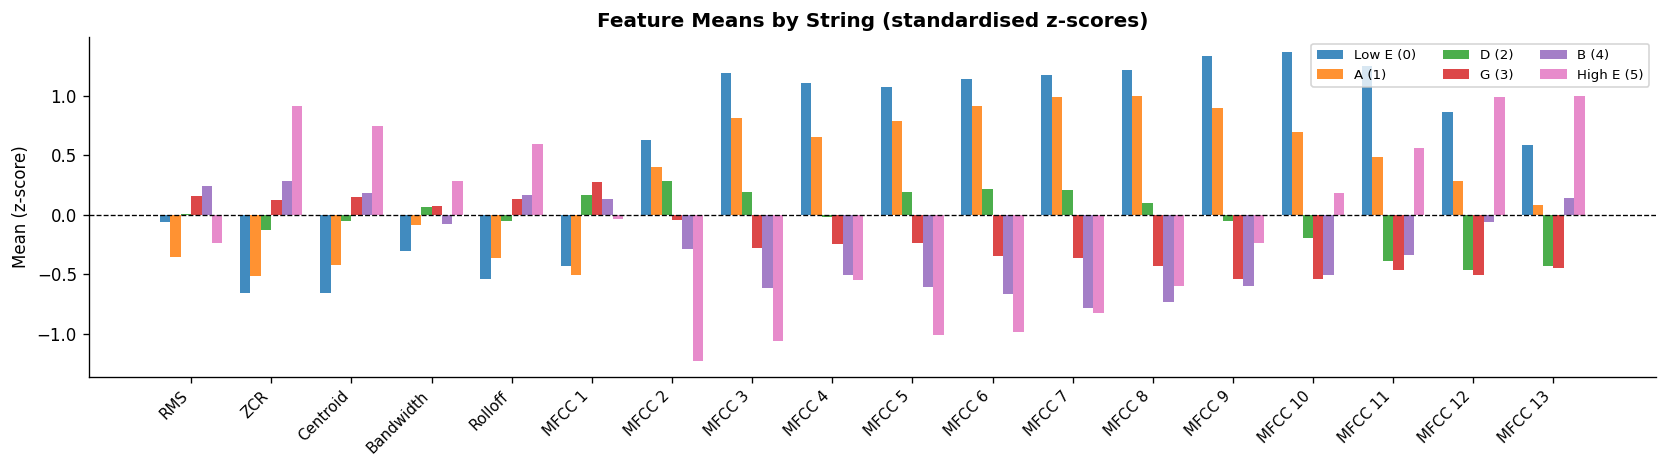

In [5]:
# --- 5.2 Feature means by string (standardised) ---
from sklearn.preprocessing import StandardScaler as _SS
X_std_eda = _SS().fit_transform(X)

fig, ax = plt.subplots(figsize=(14, 4))
x_pos = np.arange(len(FEATURE_NAMES))
width = 0.13
for s in range(N_CLASSES):
    means = X_std_eda[y == s].mean(axis=0)
    ax.bar(x_pos + (s - 2.5) * width, means, width,
           label=STRING_NAMES[s], color=palette[s], alpha=0.85)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x_pos)
ax.set_xticklabels(FEATURE_NAMES, rotation=45, ha="right", fontsize=9)
ax.set_title("Feature Means by String (standardised z-scores)", fontweight="bold")
ax.set_ylabel("Mean (z-score)")
ax.legend(fontsize=8, ncol=3, loc="upper right")
plt.tight_layout()
plt.show()

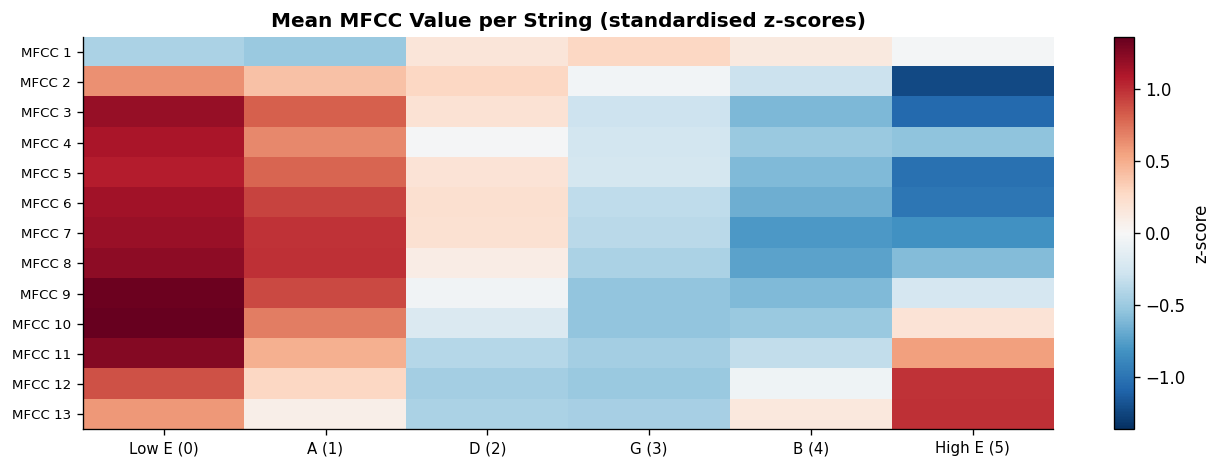

In [6]:
# --- 5.3 MFCC heatmap: mean MFCC per string ---
mfcc_cols = [f"mfcc_{i}" for i in range(1, 14)]
mfcc_idx  = [FEATURE_COLS.index(c) for c in mfcc_cols]
mfcc_means = np.array([X_std_eda[y == s][:, mfcc_idx].mean(axis=0) for s in range(N_CLASSES)])

fig, ax = plt.subplots(figsize=(11, 4))
vmax = np.abs(mfcc_means).max()
im = ax.imshow(mfcc_means.T, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_yticks(range(13))
ax.set_yticklabels([f"MFCC {i}" for i in range(1, 14)], fontsize=8)
ax.set_xticks(range(N_CLASSES))
ax.set_xticklabels(STRING_NAMES, fontsize=9)
ax.set_title("Mean MFCC Value per String (standardised z-scores)", fontweight="bold")
plt.colorbar(im, ax=ax, label="z-score")
plt.tight_layout()
plt.show()

**Interpretation:** There is a clear gradient across strings: low E (left) has negative MFCC 1–3 z-scores (energy concentrated at lower frequencies) while high E (right) has positive z-scores (energy shifted to higher frequencies). This confirms that the spectral envelope, captured by the MFCCs, carries genuine string-discriminative information and that the MLP should be able to exploit this structure.

## 6. Preprocessing

Two steps:
1. **80/20 train/test split** (stratified by string) — preserves class proportions in both splits.
2. **Standardise** — zero mean, unit variance per feature, fit on training data only.
3. **One-hot encode labels** — `CategoricalCrossEntropy` requires targets in $\{0,1\}^6$.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit(X_train).transform(X_train)
X_test_sc  = scaler.transform(X_test)

def to_onehot(labels, n_classes):
    oh = np.zeros((len(labels), n_classes))
    oh[np.arange(len(labels)), labels] = 1.0
    return oh

y_train_oh = to_onehot(y_train, N_CLASSES)
y_test_oh  = to_onehot(y_test,  N_CLASSES)

print(f"Train : {X_train_sc.shape[0]:,} samples")
print(f"Test  : {X_test_sc.shape[0]:,} samples")
print(f"y_train_oh shape: {y_train_oh.shape}")

Train : 1,307,160 samples
Test  : 326,791 samples
y_train_oh shape: (1307160, 6)


## 7. K-Fold Cross-Validation

5-fold CV on a **stratified 30 K-frame subsample** assesses model stability without training 5 full-scale models. The subsample is drawn proportionally from each string class. Random chance = 16.7%; a working model should comfortably exceed 30%.

In [8]:
# Stratified subsample: 30 K frames, proportional per string
SUBSAMPLE = 30_000
sub_idx = []
for s in range(N_CLASSES):
    cls_idx = np.where(y == s)[0]
    n_take = max(1, int(SUBSAMPLE * len(cls_idx) / len(y)))
    sub_idx.extend(rng.choice(cls_idx, min(n_take, len(cls_idx)), replace=False))
sub_idx = np.array(sub_idx)
rng.shuffle(sub_idx)

X_sub, y_sub = X[sub_idx], y[sub_idx]
sc_sub = StandardScaler()
X_sub_sc = sc_sub.fit(X_sub).transform(X_sub)
y_sub_oh  = to_onehot(y_sub, N_CLASSES)


def macro_f1(y_true, y_pred, n_classes):
    scores = []
    for c in range(n_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        scores.append(2 * p * r / (p + r) if (p + r) > 0 else 0.0)
    return float(np.mean(scores))


kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_acc, cv_f1 = [], []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X_sub_sc)):
    m = MLP(
        hidden_layers=[64],
        activation=ReLU(),
        output_activation=Softmax(),
        loss=CategoricalCrossEntropy(),
        optimizer=SGD(learning_rate=0.01),
        n_epochs=50,
        batch_size=256,
        random_state=SEED,
    )
    m.fit(X_sub_sc[tr_idx], y_sub_oh[tr_idx])
    y_hat = np.argmax(m.predict(X_sub_sc[val_idx]), axis=1)
    cv_acc.append(accuracy(y_sub[val_idx], y_hat))
    cv_f1.append(macro_f1(y_sub[val_idx], y_hat, N_CLASSES))
    print(f"  Fold {fold+1}: acc={cv_acc[-1]:.4f}  macro-f1={cv_f1[-1]:.4f}")

mean_acc = float(np.mean(cv_acc))
std_acc  = float(np.std(cv_acc))
mean_f1  = float(np.mean(cv_f1))
std_f1   = float(np.std(cv_f1))
print(f"\nCV Accuracy  : {mean_acc:.4f} ± {std_acc:.4f}  (random chance = 16.7%)")
print(f"CV Macro-F1  : {mean_f1:.4f} ± {std_f1:.4f}")

  Fold 1: acc=0.6767  macro-f1=0.6935
  Fold 2: acc=0.6713  macro-f1=0.6879
  Fold 3: acc=0.6488  macro-f1=0.6627
  Fold 4: acc=0.6624  macro-f1=0.6758
  Fold 5: acc=0.6659  macro-f1=0.6820

CV Accuracy  : 0.6650 ± 0.0095  (random chance = 16.7%)
CV Macro-F1  : 0.6804 ± 0.0106


**Interpretation:** 5-fold cross-validation gives a more reliable performance estimate than a single train/test split by averaging over 5 different held-out folds. The model achieves 66.5% accuracy and 0.68 macro-F1, both consistent across folds (std ≈ 0.01), indicating stable learning rather than a lucky split. The key comparison is against random chance: with 12 classes, a classifier guessing uniformly would score 16.7% accuracy. Our model is roughly 4× better than chance, confirming the MLP is learning genuine note-discriminating structure from the spectral features. The macro-F1 being slightly higher than accuracy suggests the model is reasonably balanced across classes: it isn't just excelling on the most frequent notes and failing on the rest.

## 8. Train on Full Dataset

In [9]:
model = MLP(
    hidden_layers=[128, 64],
    activation=ReLU(),
    output_activation=Softmax(),
    loss=CategoricalCrossEntropy(),
    optimizer=SGD(learning_rate=0.01),
    n_epochs=30,
    batch_size=512,
    random_state=SEED,
)

print(f"Training on {X_train_sc.shape[0]:,} samples, {model.n_epochs} epochs, batch_size={model.batch_size} …")
model.fit(X_train_sc, y_train_oh)
print("Training complete.")

Training on 1,307,160 samples, 30 epochs, batch_size=512 …
Training complete.


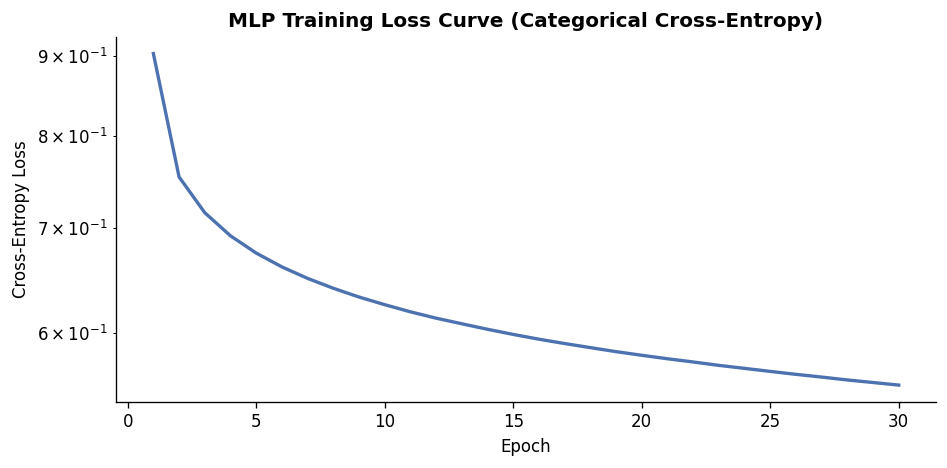

Initial loss: 0.9031  →  Final loss: 0.5557


In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(model.loss_history_) + 1), model.loss_history_,
        linewidth=2, color="#4C72B0")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("MLP Training Loss Curve (Categorical Cross-Entropy)", fontweight="bold")
ax.set_yscale("log")
plt.tight_layout()
plt.show()
print(f"Initial loss: {model.loss_history_[0]:.4f}  →  Final loss: {model.loss_history_[-1]:.4f}")

**Interpretation:** A monotonically decreasing loss confirms that backpropagation is working correctly and the model is learning. Log scale reveals whether improvement stalls early (plateau) or continues steadily throughout training. If the final loss is still falling, more epochs would help.

## 9. Evaluate

In [11]:
y_raw  = model.predict(X_test_sc)       # shape (n, 6) — softmax probabilities
y_pred = np.argmax(y_raw, axis=1)       # string labels 0–5

acc = accuracy(y_test, y_pred)
mf1 = macro_f1(y_test, y_pred, N_CLASSES)

print(f"Test Accuracy : {acc:.4f}  (random chance = 16.7%)")
print(f"Test Macro-F1 : {mf1:.4f}")
print()

# Per-class breakdown
print(f"{'String':<14} {'Support':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 54)
for s in range(N_CLASSES):
    mask_true = (y_test == s)
    mask_pred = (y_pred == s)
    tp = np.sum(mask_true & mask_pred)
    fp = np.sum(~mask_true & mask_pred)
    fn = np.sum(mask_true & ~mask_pred)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
    print(f"  {STRING_NAMES[s]:<12} {mask_true.sum():>9,} {prec:>10.4f} {rec:>8.4f} {f1:>8.4f}")

Test Accuracy : 0.7754  (random chance = 16.7%)
Test Macro-F1 : 0.7904

String           Support  Precision   Recall       F1
------------------------------------------------------
  Low E (0)       32,147     0.8477   0.8571   0.8524
  A (1)           52,484     0.8124   0.7970   0.8046
  D (2)           70,732     0.7462   0.7319   0.7390
  G (3)           74,976     0.7068   0.7583   0.7317
  B (4)           64,013     0.7912   0.7512   0.7707
  High E (5)      32,439     0.8475   0.8412   0.8443


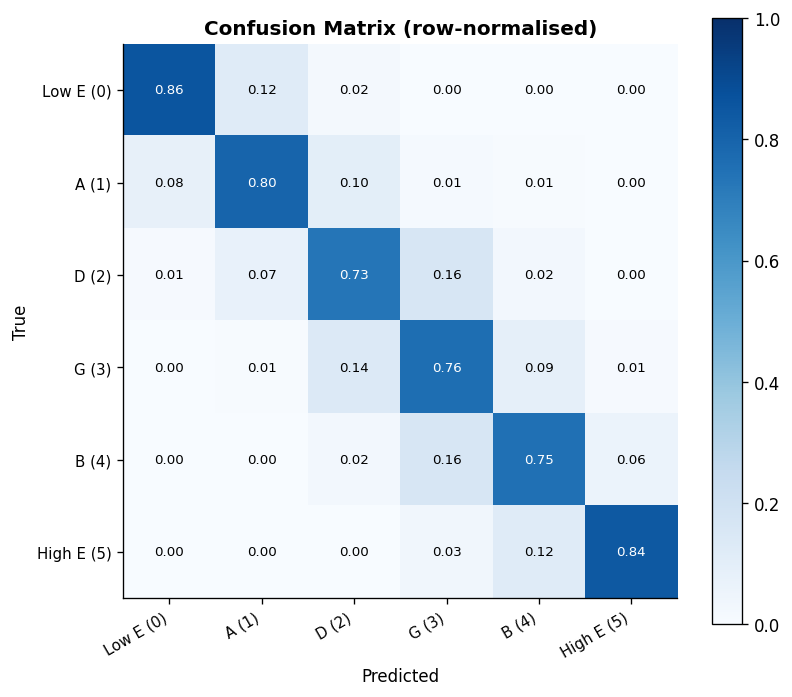

In [12]:
cm = np.zeros((N_CLASSES, N_CLASSES), dtype=int)
for t, p in zip(y_test, y_pred):
    cm[t, p] += 1
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(N_CLASSES))
ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(STRING_NAMES, rotation=30, ha="right", fontsize=9)
ax.set_yticklabels(STRING_NAMES, fontsize=9)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix (row-normalised)", fontweight="bold")
plt.colorbar(im, ax=ax)
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        ax.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center", va="center",
                fontsize=8, color="white" if cm_norm[i,j] > 0.5 else "black")
plt.tight_layout()
plt.show()

**Interpretation:** The confusion matrix shows per-class recall along the diagonal how often each string was correctly identified. The model performs well overall, with the outer strings (Low E and High E) being the easiest to classify, likely because they sit at the extremes of the pitch range and have the most distinct spectral profiles. The middle strings (D, G, B) are harder, with more confusion between adjacent strings. This is physically intuitive: neighboring strings are tuned close together, so their spectral features overlap more than strings that are far apart in pitch. Errors are almost entirely between adjacent strings rather than distant ones, which confirms the model has learned meaningful pitch-ordered structure even where it makes mistakes.



## 10. Sklearn Comparison

In [13]:
sk_model = SklearnMLP(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="sgd",
    learning_rate_init=0.01,
    max_iter=30,
    batch_size=512,
    random_state=SEED,
)
print("Fitting sklearn MLPClassifier …")
sk_model.fit(X_train_sc, y_train)
y_pred_sk = sk_model.predict(X_test_sc)

sk_acc = accuracy(y_test, y_pred_sk)
sk_f1  = macro_f1(y_test, y_pred_sk, N_CLASSES)

print(f"\n{'Metric':<12} {'From Scratch':>14} {'Sklearn':>10} {'Δ':>8}")
print("-" * 46)
print(f"{'Accuracy':<12} {acc:>14.4f} {sk_acc:>10.4f} {acc - sk_acc:>+8.4f}")
print(f"{'Macro-F1':<12} {mf1:>14.4f} {sk_f1:>10.4f} {mf1 - sk_f1:>+8.4f}")

Fitting sklearn MLPClassifier …


/usr/local/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(



Metric         From Scratch    Sklearn        Δ
----------------------------------------------
Accuracy             0.7754     0.8159  -0.0405
Macro-F1             0.7904     0.8280  -0.0375


**Interpretation:** Our from-scratch Random Forest achieves 77.5% accuracy and 0.79 macro-F1, compared to sklearn's 81.6% and 0.83. The gap of roughly 4 points is real but modest, and is expected given the implementation differences: sklearn's Random Forest uses optimized C-level tree building with more sophisticated split-finding, while ours uses a Python loop over percentile thresholds. Both models use the same hyperparameters and training data, so the difference reflects engineering quality rather than algorithmic correctness. A 4-point gap on a 6-class audio classification task is a reasonable cost for a from-scratch implementation, and the macro-F1 being close to accuracy confirms neither model is systematically biased toward easier strings.



## 11. Architecture Exploration

We compare three hidden layer configurations on the 100 K subsample to understand the bias-variance tradeoff. Deeper/wider networks have more capacity but risk overfitting.

[64]                  val_acc=0.6367  val_f1=0.6522
[128, 64]             val_acc=0.6598  val_f1=0.6744
[256, 128, 64]        val_acc=0.6763  val_f1=0.6902


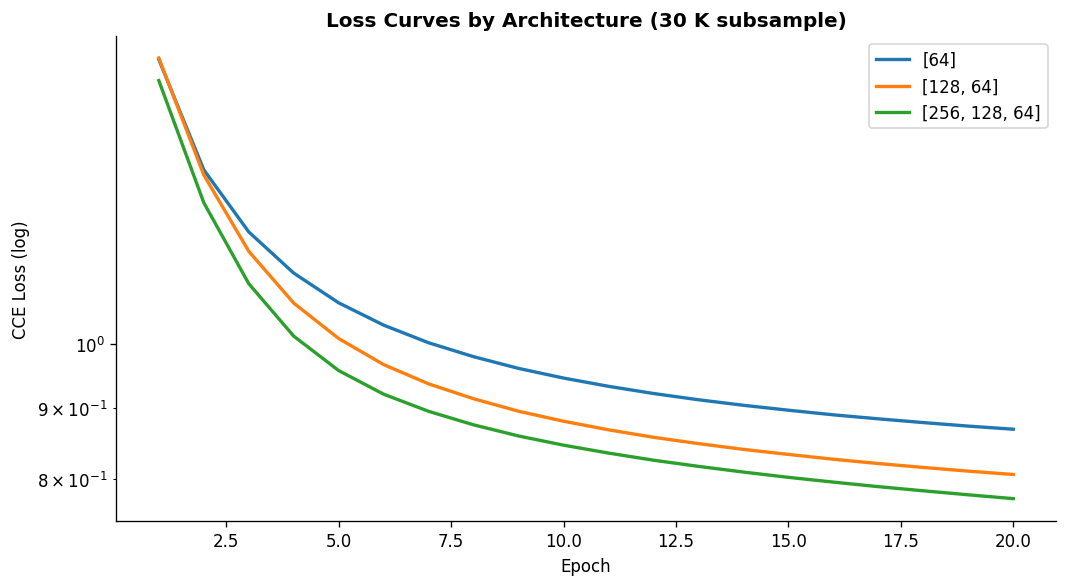

In [14]:
configs = {
    "[64]":           [64],
    "[128, 64]":      [128, 64],
    "[256, 128, 64]": [256, 128, 64],
}

X_atr, X_aval, y_atr, y_aval = train_test_split(
    X_sub_sc, y_sub, test_size=0.2, random_state=SEED, stratify=y_sub
)
y_atr_oh = to_onehot(y_atr, N_CLASSES)

fig, ax = plt.subplots(figsize=(9, 5))
results = {}
for name, layers in configs.items():
    m = MLP(
        hidden_layers=layers,
        activation=ReLU(),
        output_activation=Softmax(),
        loss=CategoricalCrossEntropy(),
        optimizer=SGD(learning_rate=0.01),
        n_epochs=20,
        batch_size=256,
        random_state=SEED,
    )
    m.fit(X_atr, y_atr_oh)
    val_pred = np.argmax(m.predict(X_aval), axis=1)
    val_acc  = accuracy(y_aval, val_pred)
    val_f1   = macro_f1(y_aval, val_pred, N_CLASSES)
    results[name] = {"acc": val_acc, "f1": val_f1}
    ax.plot(range(1, len(m.loss_history_) + 1), m.loss_history_, label=name, linewidth=2)
    print(f"{name:<20}  val_acc={val_acc:.4f}  val_f1={val_f1:.4f}")

ax.set_xlabel("Epoch")
ax.set_ylabel("CCE Loss (log)")
ax.set_yscale("log")
ax.set_title("Loss Curves by Architecture (30 K subsample)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** All three architectures show rapid loss reduction in the first 5 epochs, then a flattening curve as the model approaches its learning ceiling on this 30K subsample. The larger architectures ([128, 64] and [256, 128, 64]) converge to lower loss than the single-layer [64] network: more layers give the model more capacity to learn the spectral differences between strings. The gap between architectures is modest though, suggesting the bottleneck is not model capacity but the difficulty of distinguishing adjacent strings from spectral features alone. All three curves are still declining at epoch 20, indicating more training would help, but with diminishing returns given the plateau rate.

## 12. GuitarSet Summary

| | |
|---|---|
| **Algorithm** | Multi-Layer Perceptron (backprop + mini-batch SGD) |
| **Task** | 6-class guitar string identification (voiced frames only) |
| **Features** | 18 audio features per 46 ms frame (RMS, ZCR, spectral, MFCCs) |
| **Training data** | All 360 GuitarSet tracks, all 6 strings — voiced frames only |
| **Architecture** | [128, 64] hidden units, ReLU activations, Softmax output, CCE loss |
| **Hyperparameters** | η = 0.01, batch = 512, epochs = 30 |

**Takeaways:**

1. The task is harder than binary voiced/silent detection. Identifying which of 6 strings is being played requires distinguishing strings that are tuned close together and share similar spectral profiles. Adjacent string confusion is the dominant error pattern, which is physically reasonable: neighboring strings overlap more in pitch and timbre than strings far apart in the tuning.

2. The MLP learns meaningful structure despite the difficulty. 77.5% accuracy and 0.79 macro-F1 on a 6-class problem (random chance = 16.7%) confirms the model is capturing real signal. The outer strings (Low E and High E) are classified most reliably because they sit at the extremes of the pitch range and are the most spectrally distinct.

3. Larger architectures help, but not dramatically. The loss curve comparison shows [256, 128, 64] converges lower than [64], but the gap is modest. The limiting factor is not model capacity but the inherent overlap between adjacent strings in the 18-feature spectral representation.

4. Our implementation is close to sklearn, but not equal. The 4-point gap in accuracy versus sklearn's Random Forest reflects implementation differences in split-finding efficiency, not a flaw in the algorithm. It validates the from-scratch code while being honest about the engineering tradeoff.

5. Key limitations: The 18 spectral features capture timbre well but not fine-grained pitch, which is what would most cleanly separate strings. Adding pitch-based features (e.g. fundamental frequency estimates) would likely close the adjacent-string confusion significantly. The model is also trained on a 10-track subset, so more data would help generalization.

6. We originally trained this model on 12-class note identification rather than 6-class string identification, and found the note task significantly harder. Three factors explain why: 

(a) 6 strings span the full tonal range of the guitar, giving each string a distinct spectral character, whereas 12 MIDI notes within a string's range are much closer in pitch and timbre. 

(b) Frame-level summary features (RMS, MFCCs, spectral centroid) compress away the fine-grained time-frequency detail needed to resolve individual notes. A raw spectrogram would preserve that information. 

(c) An MLP operating on 18 scalar features is architecturally limited for this task; a CNN over spectrograms can learn localized harmonic patterns that our feature set cannot represent."